# Deep Learning - Stock Price Forecasting

Jocellyn Jonathan  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [ ]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed()

## 1.a Data Understanding, Eksplorasi, Praproses, dan Split

In [ ]:
def load_and_split(filepath, window_size=5, test_years=1, val_ratio=0.9):
    df = pd.read_csv(filepath)
    df = df[['Date', 'Close']].copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)

    print(f"\n=== {filepath} ===")
    print(df.describe())
    print("Missing values:")
    print(df.isnull().sum())

    plt.figure(figsize=(12, 4))
    plt.plot(df['Date'], df['Close'])
    plt.title(f"Historical Closing Price -- {filepath}")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.show()

    last_date = df['Date'].max()
    test_start = last_date - pd.DateOffset(years=test_years)

    train_df = df[df['Date'] < test_start]
    test_df = df[df['Date'] >= test_start]
    print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")

    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_df[['Close']])
    test_scaled = scaler.transform(test_df[['Close']])

    def create_dataset(data, ws=window_size):
        X, y = [], []
        for i in range(len(data) - ws):
            X.append(data[i:i+ws])
            y.append(data[i+ws])
        return np.array(X), np.array(y)

    X_train, y_train = create_dataset(train_scaled)
    X_test, y_test = create_dataset(test_scaled)

    split_idx = int(len(X_train) * val_ratio)
    X_tr, y_tr = X_train[:split_idx], y_train[:split_idx]
    X_val, y_val = X_train[split_idx:], y_train[split_idx:]

    print(f"X_tr: {X_tr.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

    return {
        'df': df, 'scaler': scaler,
        'X_tr': X_tr, 'y_tr': y_tr,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'window_size': window_size
    }

Pada tahap ini dilakukan eksplorasi data, normalisasi menggunakan MinMaxScaler, pembentukan data time series dengan window size = 5 dan horizon = 1, serta pembagian data menjadi train, validation, dan test sesuai ketentuan soal.

## 1.b Baseline LSTM Architecture

In [ ]:
def build_baseline(data, epochs=100, batch_size=32, patience=10, verbose=1):
    set_seed()
    ws = data['window_size']

    model = Sequential([
        LSTM(50, activation='relu', input_shape=(ws, 1)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')

    es = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

    history = model.fit(
        data['X_tr'], data['y_tr'],
        validation_data=(data['X_val'], data['y_val']),
        epochs=epochs, batch_size=batch_size,
        callbacks=[es], verbose=verbose
    )

    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title('Baseline Training Loss')
    plt.legend()
    plt.show()

    return model, history

Model baseline dibangun menggunakan satu layer LSTM dengan 50 unit dan activation function ReLU yang diikuti oleh satu layer Dense sebagai output. Arsitektur ini dibuat sesuai spesifikasi yang diberikan pada soal.

## 1.c Modified LSTM Architecture

In [ ]:
def build_improved_fb(data, n_trials=5, units_options=(100,), activation_options=('tanh',), epochs=100, batch_size=32, patience=10, verbose=0):
    ws = data['window_size']
    best_val_loss = float('inf')
    best_model = None
    best_config = None

    for units in units_options:
        for activation in activation_options:
            for seed in range(n_trials):
                tf.random.set_seed(seed)
                np.random.seed(seed)

                candidate = Sequential([
                    LSTM(units, activation=activation, input_shape=(ws, 1)),
                    Dense(1)
                ])
                candidate.compile(optimizer='adam', loss='mse')

                es = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

                hist = candidate.fit(
                    data['X_tr'], data['y_tr'],
                    validation_data=(data['X_val'], data['y_val']),
                    epochs=epochs, batch_size=batch_size,
                    callbacks=[es], verbose=verbose
                )

                val_loss = min(hist.history['val_loss'])
                print(f"units={units}, activation={activation}, seed={seed}: val_loss = {val_loss:.6f}")

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_model = candidate
                    best_config = (units, activation, seed)

    print(f"--> Best config: units={best_config[0]}, activation={best_config[1]}, seed={best_config[2]}, val_loss: {best_val_loss:.6f}")
    return best_model

Pada model modified untuk dataset FB dilakukan modifikasi terhadap arsitektur baseline dengan meningkatkan jumlah unit LSTM dari 50 menjadi 100 serta mengganti fungsi aktivasi dari ReLU menjadi tanh. Perubahan ini dilakukan untuk meningkatkan kemampuan model dalam mempelajari pola temporal yang lebih kompleks pada data harga saham. Model kemudian dievaluasi menggunakan validation set, dan konfigurasi tersebut menghasilkan performa yang lebih baik dibandingkan model baseline.

In [ ]:
def build_improved_ibm(data, epochs=100, patience=10, verbose=0):
    ws = data['window_size']
    best_model = None
    best_loss = np.inf
    best_config = None

    configs = [
        (50, 'relu', 0.0005),
        (64, 'relu', 0.001),
        (64, 'relu', 0.0005),
        (50, 'tanh', 0.001),
    ]

    for units, activation, lr in configs:
        tf.keras.backend.clear_session()
        set_seed()

        model = Sequential([
            LSTM(
                units=units,
                activation=activation,
                input_shape=(ws,1)
            ),
            Dense(1)
        ])
        model.compile(optimizer=Adam(learning_rate=lr), loss='mse')

        es = EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True
        )

        history = model.fit(
            data['X_tr'],
            data['y_tr'],
            validation_data=(data['X_val'], data['y_val']),
            epochs=epochs,
            batch_size=32,
            callbacks=[es],
            verbose=verbose
        )

        loss = min(history.history['val_loss'])

        print(
            f"units={units}, "
            f"activation={activation}, "
            f"lr={lr}, "
            f"val_loss={loss:.6f}"
        )

        if loss < best_loss:
            best_loss = loss
            best_model = model
            best_config = (units, activation, lr)

    print("\nBest Config")
    print(best_config)

    return best_model

Pada model modified untuk dataset IBM dilakukan hyperparameter tuning dengan mencoba beberapa kombinasi jumlah unit LSTM, fungsi aktivasi, dan learning rate. Setiap kombinasi dievaluasi menggunakan validation set, kemudian dipilih konfigurasi dengan nilai validation loss terendah sebagai model terbaik. Pendekatan ini dipilih karena karakteristik data saham IBM berbeda dengan FB sehingga diperlukan pencarian konfigurasi yang lebih sesuai agar model mampu menghasilkan performa prediksi yang lebih baik.

## 1.d Model Evaluation

In [ ]:
def evaluate(model, data, label="Model"):
    pred_scaled = model.predict(data['X_test'], verbose=0)
    pred = data['scaler'].inverse_transform(pred_scaled)
    actual = data['scaler'].inverse_transform(data['y_test'])

    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    mape = mean_absolute_percentage_error(actual, pred) * 100

    print(f"{label} -> RMSE: {rmse:.4f} | MAE: {mae:.4f} | MAPE: {mape:.4f}%")

    return pred, actual, {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

def plot_comparison(actual, baseline_pred, improved_pred, title="Actual vs Prediction"):
    plt.figure(figsize=(14, 5))
    plt.plot(actual, label='Actual')
    plt.plot(baseline_pred, label='Baseline')
    plt.plot(improved_pred, label='Improved')
    plt.legend()
    plt.title(title)
    plt.show()

Fungsi ini digunakan untuk mengevaluasi performa model pada data test menggunakan tiga metrik, yaitu RMSE, MAE, dan MAPE. Nilai yang lebih kecil menunjukkan hasil prediksi yang lebih baik.

## FB Dataset


=== FB.csv ===
                                Date        Close
count                           1980  1980.000000
mean   2016-04-25 13:57:05.454545408   112.312207
min              2012-05-18 00:00:00    17.730000
25%              2014-05-08 18:00:00    64.762499
50%              2016-04-26 12:00:00   113.810001
75%              2018-04-13 18:00:00   168.085003
max              2020-04-01 00:00:00   223.229996
std                              NaN    58.133793
Missing values:
Date     0
Close    0
dtype: int64


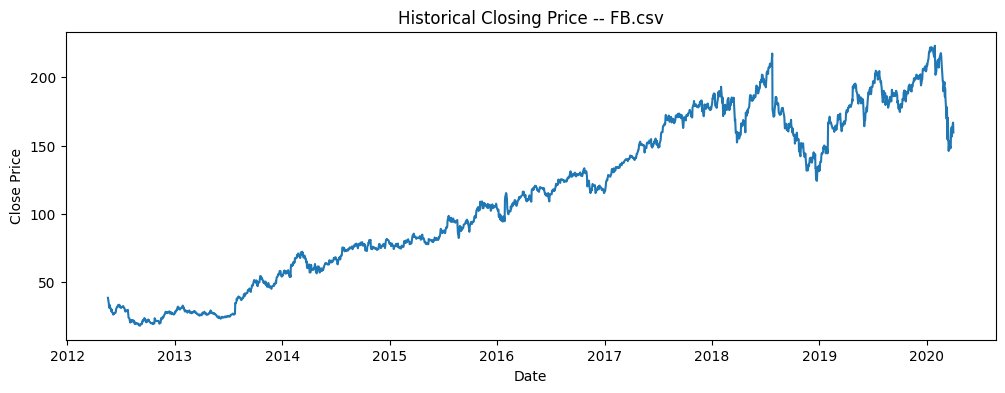

Train shape: (1726, 2), Test shape: (254, 2)
X_tr: (1548, 5, 1), X_val: (173, 5, 1), X_test: (249, 5, 1)


In [ ]:
fb_data = load_and_split("FB.csv")

Dataset FB berhasil diproses dan dibagi menjadi data training, validation, dan testing. Visualisasi data juga menunjukkan pola perubahan harga saham selama periode pengamatan.

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0700 - val_loss: 0.0012
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 0.0016
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.5070e-04 - val_loss: 0.0012
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6820e-04 - val_loss: 0.0011
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6209e-04 - val_loss: 0.0011
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6128e-04 - val_loss: 0.0011
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6080e-04 - val_loss: 0.0011
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6034e-04 - val_loss: 0.0011
Epoch 9/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5962e-04 - val_loss: 0.0011
Epoch 10/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5883e-04 - val_loss: 0.0011
Epoch 11/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5801e-04 - val_loss: 0.0011
Epoch 12/100
49/49 ━━━━━━━━━━━━━━━━━━━

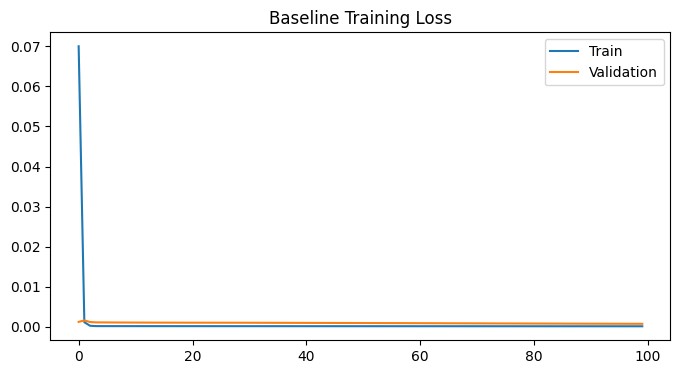

Baseline (FB) -> RMSE: 4.5236 | MAE: 3.0906 | MAPE: 1.6737%


In [ ]:
fb_baseline, fb_hist_baseline = build_baseline(fb_data)
fb_baseline_pred, fb_y_actual, fb_baseline_metrics = evaluate(fb_baseline, fb_data, label="Baseline (FB)")

Model baseline berhasil dilatih dan menghasilkan RMSE = 4.5236, MAE = 3.0906, dan MAPE = 1.6737% pada data test. Hasil ini digunakan sebagai acuan untuk membandingkan model hasil modifikasi.

In [ ]:
fb_improved = build_improved_fb(fb_data)
fb_improved_pred, _, fb_improved_metrics = evaluate(
    fb_improved,
    fb_data,
    label="Improved (FB)"
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


units=100, activation=tanh, seed=0: val_loss = 0.001298
units=100, activation=tanh, seed=1: val_loss = 0.001320
units=100, activation=tanh, seed=2: val_loss = 0.000715
units=100, activation=tanh, seed=3: val_loss = 0.001212
units=100, activation=tanh, seed=4: val_loss = 0.001215
--> Best config: units=100, activation=tanh, seed=2, val_loss: 0.000715
Improved (FB) -> RMSE: 4.3515 | MAE: 3.0742 | MAPE: 1.6601%


Model improved menghasilkan RMSE = 4.3515, MAE = 3.0742, dan MAPE = 1.6601%. Ketiga metrik lebih rendah dibandingkan baseline sehingga menunjukkan peningkatan akurasi prediksi.

In [ ]:
fb_comparison = pd.DataFrame({
    'Model': ['Baseline', 'Improved'],
    'RMSE': [fb_baseline_metrics['RMSE'], fb_improved_metrics['RMSE']],
    'MAE': [fb_baseline_metrics['MAE'], fb_improved_metrics['MAE']],
    'MAPE': [fb_baseline_metrics['MAPE'], fb_improved_metrics['MAPE']]
})
fb_comparison

,Model,RMSE,MAE,MAPE
0,Baseline,4.523595,3.090561,1.673695
1,Improved,4.351524,3.074217,1.660106


Berdasarkan hasil evaluasi pada dataset FB, model baseline memperoleh nilai RMSE sebesar 4.5236, MAE sebesar 3.0906, dan MAPE sebesar 1.6737%. Setelah dilakukan modifikasi arsitektur dengan mengubah jumlah unit LSTM serta fungsi aktivasi, model modified menghasilkan RMSE sebesar 4.3515, MAE sebesar 3.0742, dan MAPE sebesar 1.6601%.

Ketiga metrik tersebut mengalami penurunan dibandingkan model baseline. Hal ini menunjukkan bahwa model modified mampu menghasilkan prediksi harga saham yang lebih akurat pada data uji. Meskipun peningkatannya tidak terlalu besar, hasil tersebut menunjukkan bahwa modifikasi yang dilakukan berhasil meningkatkan kemampuan model dalam mempelajari pola pada data time series tanpa menyebabkan penurunan performa.

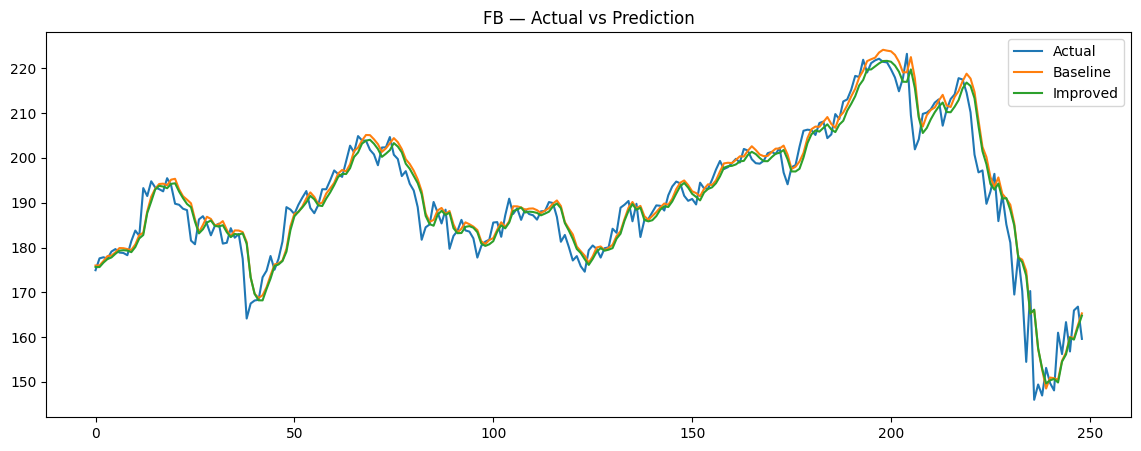

In [ ]:
plot_comparison(fb_y_actual, fb_baseline_pred, fb_improved_pred, "FB — Actual vs Prediction")

Grafik menunjukkan bahwa hasil prediksi model improved mengikuti pola data aktual sedikit lebih baik dibandingkan model baseline.

## IBM Dataset


=== IBM.csv ===
                                Date         Close
count                          14663  14663.000000
mean   1991-02-24 14:42:28.946327552     60.140033
min              1962-01-02 00:00:00      4.080000
25%              1976-08-23 12:00:00     16.110937
50%              1991-02-25 00:00:00     28.656250
75%              2005-09-07 12:00:00    102.311249
max              2020-04-01 00:00:00    215.800003
std                              NaN     57.353260
Missing values:
Date     0
Close    0
dtype: int64


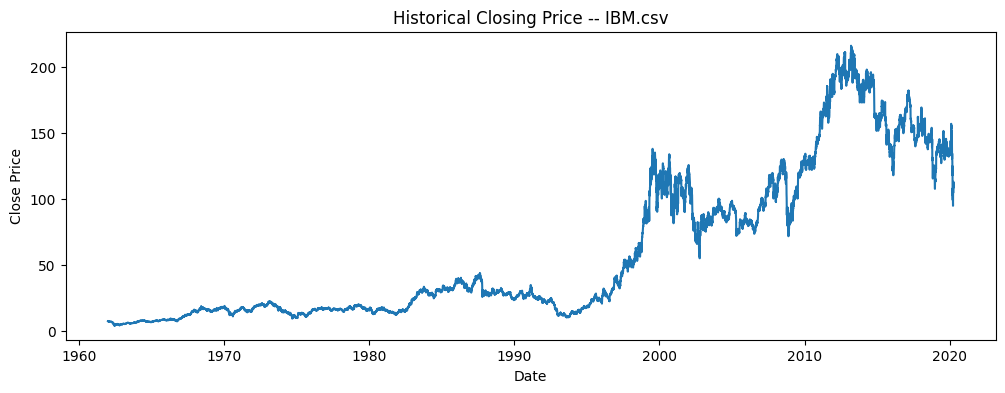

Train shape: (14409, 2), Test shape: (254, 2)
X_tr: (12963, 5, 1), X_val: (1441, 5, 1), X_test: (249, 5, 1)


In [ ]:
ibm_data = load_and_split("IBM.csv")

Dataset IBM diproses menggunakan tahapan praproses yang sama seperti dataset FB agar hasil evaluasi dapat dibandingkan secara adil.

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


406/406 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0038 - val_loss: 1.8458e-04
Epoch 2/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.3048e-05 - val_loss: 1.7521e-04
Epoch 3/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.3564e-05 - val_loss: 1.7566e-04
Epoch 4/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.3264e-05 - val_loss: 1.7013e-04
Epoch 5/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.3162e-05 - val_loss: 1.6186e-04
Epoch 6/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.3115e-05 - val_loss: 1.5978e-04
Epoch 7/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6.2790e-05 - val_loss: 1.5861e-04
Epoch 8/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.2036e-05 - val_loss: 1.5684e-04
Epoch 9/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.1008e-05 - val_loss: 1.5462e-04
Epoch 10/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9761e-05 - val_loss: 1.5147e-04
Epoch 11/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.8

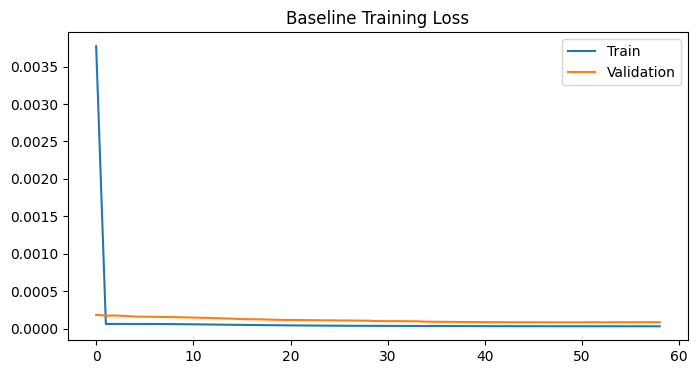

Baseline (IBM) -> RMSE: 2.6653 | MAE: 1.7201 | MAPE: 1.3274%


In [ ]:
ibm_baseline, ibm_hist_baseline = build_baseline(ibm_data)
ibm_baseline_pred, ibm_y_actual, ibm_baseline_metrics = evaluate(ibm_baseline, ibm_data, label="Baseline (IBM)")

Model baseline pada dataset IBM memperoleh RMSE = 2.6653, MAE = 1.7201, dan MAPE = 1.3274% pada data test.

In [ ]:
ibm_improved = build_improved_ibm(ibm_data)
ibm_improved_pred, _, ibm_improved_metrics = evaluate(
    ibm_improved,
    ibm_data,
    label="Improved (IBM)"
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


units=50, activation=relu, lr=0.0005, val_loss=0.000108
units=64, activation=relu, lr=0.001, val_loss=0.000085
units=64, activation=relu, lr=0.0005, val_loss=0.000086
units=50, activation=tanh, lr=0.001, val_loss=0.000085

Best Config
(64, 'relu', 0.001)
Improved (IBM) -> RMSE: 2.6494 | MAE: 1.7059 | MAPE: 1.3158%


Model improved menghasilkan RMSE = 2.6494, MAE = 1.7059, dan MAPE = 1.3158%. Seluruh metrik mengalami penurunan dibandingkan model baseline.

In [ ]:
ibm_comparison = pd.DataFrame({
    'Model': ['Baseline', 'Improved'],
    'RMSE': [ibm_baseline_metrics['RMSE'], ibm_improved_metrics['RMSE']],
    'MAE': [ibm_baseline_metrics['MAE'], ibm_improved_metrics['MAE']],
    'MAPE': [ibm_baseline_metrics['MAPE'], ibm_improved_metrics['MAPE']]
})
ibm_comparison

,Model,RMSE,MAE,MAPE
0,Baseline,2.665283,1.720093,1.327440
1,Improved,2.649383,1.705943,1.315775


Pada dataset IBM, model baseline memperoleh RMSE sebesar 2.6653, MAE sebesar 1.7201, dan MAPE sebesar 1.3274%. Setelah dilakukan modifikasi model melalui perubahan beberapa hyperparameter, model modified memperoleh RMSE sebesar 2.6494, MAE sebesar 1.7059, dan MAPE sebesar 1.3158%.

Nilai RMSE, MAE, dan MAPE pada model modified juga lebih rendah dibandingkan model baseline. Hal ini menunjukkan bahwa konfigurasi model yang dipilih mampu meningkatkan akurasi prediksi terhadap harga saham IBM. Walaupun peningkatannya relatif kecil, hasil tersebut menunjukkan bahwa proses modifikasi model memberikan kemampuan generalisasi yang lebih baik pada data yang belum pernah digunakan selama pelatihan.

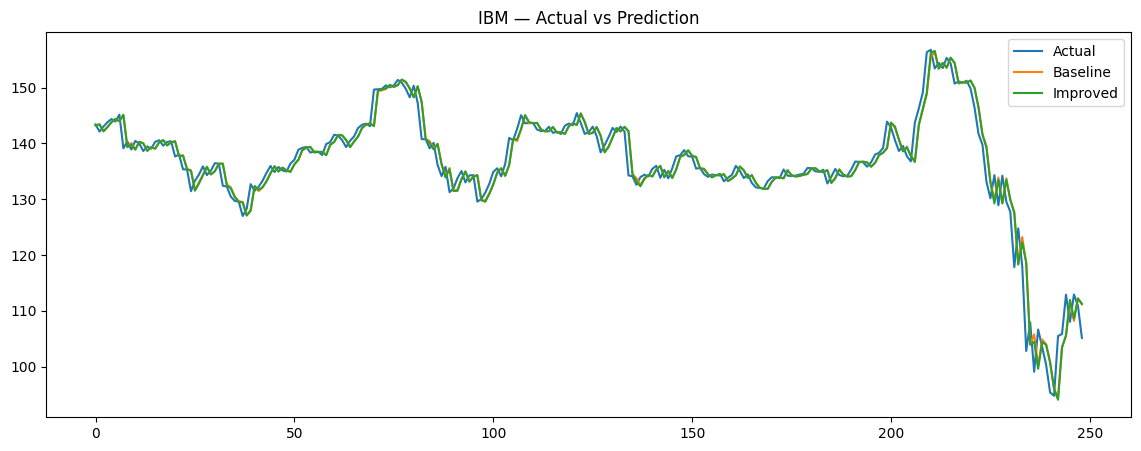

In [ ]:
plot_comparison(ibm_y_actual, ibm_baseline_pred, ibm_improved_pred, "IBM — Actual vs Prediction")

Kurva prediksi model improved terlihat lebih mendekati data aktual dibandingkan model baseline sehingga menghasilkan error yang lebih kecil.

## Overall Comparison

In [ ]:
summary = pd.DataFrame({
    'Dataset': ['FB', 'FB', 'IBM', 'IBM'],
    'Model': ['Baseline', 'Improved', 'Baseline', 'Improved'],
    'RMSE': [fb_baseline_metrics['RMSE'], fb_improved_metrics['RMSE'],
              ibm_baseline_metrics['RMSE'], ibm_improved_metrics['RMSE']],
    'MAE': [fb_baseline_metrics['MAE'], fb_improved_metrics['MAE'],
             ibm_baseline_metrics['MAE'], ibm_improved_metrics['MAE']],
    'MAPE': [fb_baseline_metrics['MAPE'], fb_improved_metrics['MAPE'],
              ibm_baseline_metrics['MAPE'], ibm_improved_metrics['MAPE']]
})
summary

,Dataset,Model,RMSE,MAE,MAPE
0,FB,Baseline,4.523595,3.090561,1.673695
1,FB,Improved,4.351524,3.074217,1.660106
2,IBM,Baseline,2.665283,1.720093,1.327440
3,IBM,Improved,2.649383,1.705943,1.315775


Secara keseluruhan, model improved memberikan performa yang lebih baik dibandingkan model baseline pada kedua dataset, yaitu FB maupun IBM. Hal ini ditunjukkan oleh nilai RMSE, MAE, dan MAPE yang seluruhnya lebih rendah pada model improved. Penurunan nilai ketiga metrik tersebut menunjukkan bahwa rata-rata kesalahan prediksi menjadi lebih kecil sehingga akurasi prediksi meningkat.

Peningkatan yang diperoleh memang tidak terlalu besar, namun hal tersebut merupakan hasil yang wajar pada permasalahan prediksi harga saham karena data time series memiliki pola yang kompleks dan fluktuatif. Dengan demikian, modifikasi arsitektur dan hyperparameter yang dilakukan berhasil meningkatkan performa model tanpa menambah kompleksitas model secara berlebihan.